Sensitivity analyses based on k, as proposed in manuscript revisions.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import scanpy as sc
import spotsweeper.local_outliers as lo

# ---------------------------------------------------------------------
# Paths, CHANGE if needed
# ---------------------------------------------------------------------

VISIUM_PATH = Path("/users/xchen5/SpotSweeper-py-paper/visium.h5ad")
HD8_PATH = Path("/users/xchen5/SpotSweeper-py-paper/hd8um.h5ad")

# ---------------------------------------------------------------------
# Load datasets
# ---------------------------------------------------------------------

visium = sc.read_h5ad(VISIUM_PATH)
hd8 = sc.read_h5ad(HD8_PATH)

print("Visium:", visium.shape)
print("Visium HD 8um:", hd8.shape)

Visium: (4169, 18085)
Visium HD 8um: (663857, 18085)


In [6]:
VISIUM_K = [6, 18, 36, 60, 90]
HD8_K = [8, 24, 48, 80, 120]

VISIUM_DEFAULT_K = 36
HD8_DEFAULT_K = 48

metric_config = {
    "log_total_counts": {
        "direction": "lower",
        "label": "Log total counts",
    },
    "n_genes_by_counts": {
        "direction": "lower",
        "label": "Number of genes",
    },
    "pct_counts_mt": {
        "direction": "higher",
        "label": "% mitochondrial counts",
    },
}

In [7]:
def run_k_sensitivity(
    adata,
    k_values,
    metric_config,
    sample_key="region",
):
    """
    Run SpotSweeper local outlier detection over multiple neighborhood sizes.

    Results are retained in adata.obs using columns such as:
        log_total_counts_outliers_k6
        log_total_counts_z_k6

    Parameters
    ----------
    adata
        AnnData object.
    k_values
        Iterable of neighborhood sizes.
    metric_config
        Dictionary mapping metric names to direction/label.
    sample_key
        Column used to define independent samples.

    Returns
    -------
    adata
        Updated AnnData object.
    summary_df
        Long-format table with number/proportion of spots flagged.
    """

    summary_rows = []

    for k in k_values:
        print(f"\n{'=' * 70}")
        print(f"Running k = {k}")
        print(f"{'=' * 70}")

        per_metric_flag_cols = []

        for metric, info in metric_config.items():
            direction = info["direction"]

            print(f"  {metric} ({direction})")

            # Same SpotSweeper settings used in the manuscript notebooks,
            # varying only n_neighbors.
            lo.local_outliers(
                adata,
                metric=metric,
                direction=direction,
                n_neighbors=k,
                sample_key=sample_key,
            )

            # Standard output columns produced by SpotSweeper
            z_col = f"{metric}_z"
            outlier_col = f"{metric}_outliers"

            # Preserve this specific k result
            saved_z_col = f"{metric}_z_k{k}"
            saved_outlier_col = f"{metric}_outliers_k{k}"

            adata.obs[saved_z_col] = adata.obs[z_col].astype(float).copy()
            adata.obs[saved_outlier_col] = (
                adata.obs[outlier_col].astype(bool).copy()
            )

            per_metric_flag_cols.append(saved_outlier_col)

            n_flagged = int(adata.obs[saved_outlier_col].sum())
            n_total = adata.n_obs
            pct_flagged = 100 * n_flagged / n_total

            summary_rows.append({
                "k": k,
                "metric": metric,
                "metric_label": info["label"],
                "n_flagged": n_flagged,
                "n_total": n_total,
                "pct_flagged": pct_flagged,
            })

            print(
                f"    flagged: {n_flagged:,}/{n_total:,} "
                f"({pct_flagged:.3f}%)"
            )

        # -------------------------------------------------------------
        # Any-metric union at this k
        # -------------------------------------------------------------

        union_col = f"any_local_metric_outlier_k{k}"

        adata.obs[union_col] = (
            adata.obs[per_metric_flag_cols]
            .astype(bool)
            .any(axis=1)
        )

        n_flagged = int(adata.obs[union_col].sum())
        n_total = adata.n_obs
        pct_flagged = 100 * n_flagged / n_total

        summary_rows.append({
            "k": k,
            "metric": "any_metric",
            "metric_label": "Any metric",
            "n_flagged": n_flagged,
            "n_total": n_total,
            "pct_flagged": pct_flagged,
        })

        print(
            f"  ANY METRIC: {n_flagged:,}/{n_total:,} "
            f"({pct_flagged:.3f}%)"
        )

    summary_df = pd.DataFrame(summary_rows)

    return adata, summary_df

In [8]:
visium, visium_summary = run_k_sensitivity(
    adata=visium,
    k_values=VISIUM_K,
    metric_config=metric_config,
    sample_key="region",
)

visium_summary


Running k = 6
  log_total_counts (lower)
    flagged: 131/4,169 (3.142%)
  n_genes_by_counts (lower)
    flagged: 137/4,169 (3.286%)
  pct_counts_mt (higher)
    flagged: 116/4,169 (2.782%)
  ANY METRIC: 311/4,169 (7.460%)

Running k = 18
  log_total_counts (lower)
    flagged: 50/4,169 (1.199%)
  n_genes_by_counts (lower)
    flagged: 67/4,169 (1.607%)
  pct_counts_mt (higher)
    flagged: 28/4,169 (0.672%)
  ANY METRIC: 106/4,169 (2.543%)

Running k = 36
  log_total_counts (lower)
    flagged: 47/4,169 (1.127%)
  n_genes_by_counts (lower)
    flagged: 80/4,169 (1.919%)
  pct_counts_mt (higher)
    flagged: 16/4,169 (0.384%)
  ANY METRIC: 101/4,169 (2.423%)

Running k = 60
  log_total_counts (lower)
    flagged: 63/4,169 (1.511%)
  n_genes_by_counts (lower)
    flagged: 88/4,169 (2.111%)
  pct_counts_mt (higher)
    flagged: 18/4,169 (0.432%)
  ANY METRIC: 115/4,169 (2.758%)

Running k = 90
  log_total_counts (lower)
    flagged: 76/4,169 (1.823%)
  n_genes_by_counts (lower)
    flag

,k,metric,metric_label,n_flagged,n_total,pct_flagged
0,6,log_total_counts,Log total counts,131,4169,3.142240
1,6,n_genes_by_counts,Number of genes,137,4169,3.286160
2,6,pct_counts_mt,% mitochondrial counts,116,4169,2.782442
3,6,any_metric,Any metric,311,4169,7.459822
4,18,log_total_counts,Log total counts,50,4169,1.199328
5,18,n_genes_by_counts,Number of genes,67,4169,1.607100
6,18,pct_counts_mt,% mitochondrial counts,28,4169,0.671624
7,18,any_metric,Any metric,106,4169,2.542576
8,36,log_total_counts,Log total counts,47,4169,1.127369
9,36,n_genes_by_counts,Number of genes,80,4169,1.918925


In [9]:
visium_flagged_table = (
    visium_summary
    .pivot(
        index="k",
        columns="metric_label",
        values="pct_flagged",
    )
    .round(3)
)

visium_flagged_table

metric_label,% mitochondrial counts,Any metric,Log total counts,Number of genes
k,,,,
6,2.782,7.460,3.142,3.286
18,0.672,2.543,1.199,1.607
36,0.384,2.423,1.127,1.919
60,0.432,2.758,1.511,2.111
90,0.408,3.142,1.823,2.591


In [10]:
hd8, hd8_summary = run_k_sensitivity(
    adata=hd8,
    k_values=HD8_K,
    metric_config=metric_config,
    sample_key="region",
)

hd8_summary


Running k = 8
  log_total_counts (lower)
    flagged: 21,578/663,857 (3.250%)
  n_genes_by_counts (lower)
    flagged: 18,226/663,857 (2.745%)
  pct_counts_mt (higher)
    flagged: 8,291/663,857 (1.249%)
  ANY METRIC: 32,816/663,857 (4.943%)

Running k = 24
  log_total_counts (lower)
    flagged: 10,618/663,857 (1.599%)
  n_genes_by_counts (lower)
    flagged: 7,339/663,857 (1.106%)
  pct_counts_mt (higher)
    flagged: 2,098/663,857 (0.316%)
  ANY METRIC: 13,246/663,857 (1.995%)

Running k = 48
  log_total_counts (lower)
    flagged: 10,551/663,857 (1.589%)
  n_genes_by_counts (lower)
    flagged: 7,227/663,857 (1.089%)
  pct_counts_mt (higher)
    flagged: 1,481/663,857 (0.223%)
  ANY METRIC: 12,173/663,857 (1.834%)

Running k = 80
  log_total_counts (lower)
    flagged: 11,754/663,857 (1.771%)
  n_genes_by_counts (lower)
    flagged: 8,192/663,857 (1.234%)
  pct_counts_mt (higher)
    flagged: 1,236/663,857 (0.186%)
  ANY METRIC: 12,979/663,857 (1.955%)

Running k = 120
  log_total

,k,metric,metric_label,n_flagged,n_total,pct_flagged
0,8,log_total_counts,Log total counts,21578,663857,3.250399
1,8,n_genes_by_counts,Number of genes,18226,663857,2.745471
2,8,pct_counts_mt,% mitochondrial counts,8291,663857,1.248914
3,8,any_metric,Any metric,32816,663857,4.943233
4,24,log_total_counts,Log total counts,10618,663857,1.599441
5,24,n_genes_by_counts,Number of genes,7339,663857,1.105509
6,24,pct_counts_mt,% mitochondrial counts,2098,663857,0.316032
7,24,any_metric,Any metric,13246,663857,1.995309
8,48,log_total_counts,Log total counts,10551,663857,1.589348
9,48,n_genes_by_counts,Number of genes,7227,663857,1.088638


In [11]:
hd8_flagged_table = (
    hd8_summary
    .pivot(
        index="k",
        columns="metric_label",
        values="pct_flagged",
    )
    .round(3)
)

hd8_flagged_table

metric_label,% mitochondrial counts,Any metric,Log total counts,Number of genes
k,,,,
8,1.249,4.943,3.250,2.745
24,0.316,1.995,1.599,1.106
48,0.223,1.834,1.589,1.089
80,0.186,1.955,1.771,1.234
120,0.162,2.077,1.927,1.361


Visualizations:

In [28]:
def plot_flagged_vs_k(summary_df, title, reference_k):
    fig, ax = plt.subplots(figsize=(7, 5))

    metric_order = [
        "Log total counts",
        "Number of genes",
        "% mitochondrial counts",
        "Any metric",
    ]

    for metric_label in metric_order:
        sub = (
            summary_df[
                summary_df["metric_label"] == metric_label
            ]
            .sort_values("k")
        )

        ax.plot(
            sub["k"],
            sub["pct_flagged"],
            marker="o",
            label=metric_label,
        )

    ax.axvline(
        reference_k,
        linestyle="--",
        linewidth=1.2,
        label=f"k = {reference_k}",
    )

    ax.set_xlabel("Number of nearest neighbors (k)")
    ax.set_ylabel("Spots/bins flagged (%)")
    ax.set_title(title)
    ax.legend(frameon=False)

    plt.tight_layout()

    return fig, ax

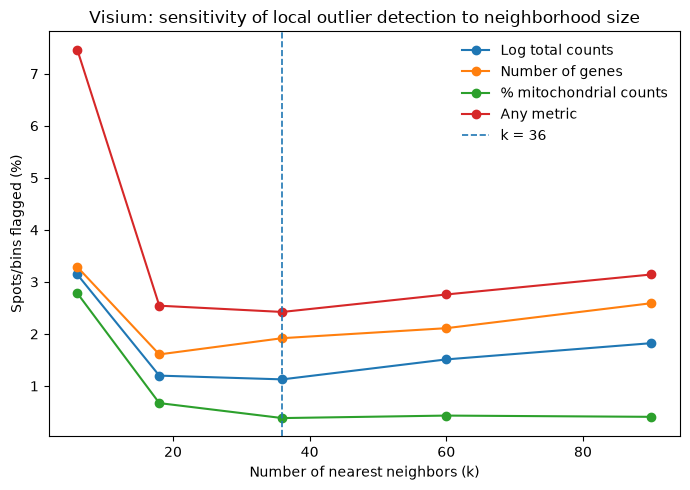

In [29]:
fig, ax = plot_flagged_vs_k(
    visium_summary,
    title="Visium: sensitivity of local outlier detection to neighborhood size",
    reference_k=VISIUM_DEFAULT_K,
)

plt.show()

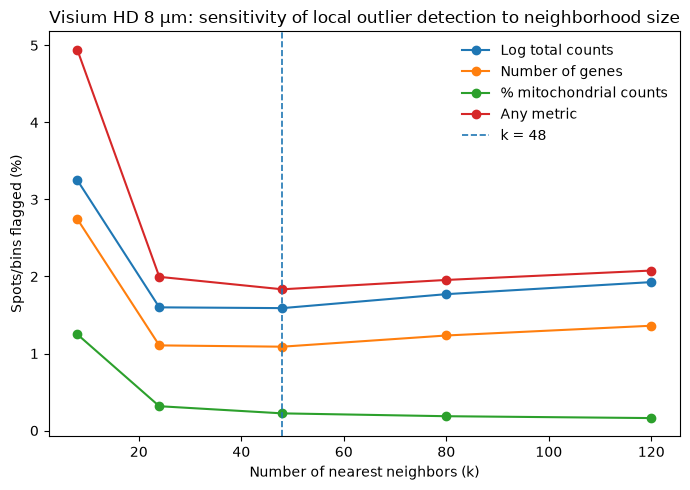

In [30]:
fig, ax = plot_flagged_vs_k(
    hd8_summary,
    title="Visium HD 8 µm: sensitivity of local outlier detection to neighborhood size",
    reference_k=HD8_DEFAULT_K,
)

plt.show()

In [19]:
def jaccard_similarity(a, b):
    a = np.asarray(a, dtype=bool)
    b = np.asarray(b, dtype=bool)

    intersection = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()

    if union == 0:
        return 1.0

    return intersection / union

def compute_k_jaccard(
    adata,
    k_values,
    reference_k,
    metric_config,
):
    """
    Compute Jaccard similarity between outlier calls at each k
    and the manuscript/default neighborhood size.
    """

    rows = []

    metrics = list(metric_config.keys()) + ["any_metric"]

    for metric in metrics:

        if metric == "any_metric":
            reference_col = f"any_local_metric_outlier_k{reference_k}"
            metric_label = "Any metric"
        else:
            reference_col = f"{metric}_outliers_k{reference_k}"
            metric_label = metric_config[metric]["label"]

        reference_flag = adata.obs[reference_col].astype(bool)

        for k in k_values:

            if metric == "any_metric":
                test_col = f"any_local_metric_outlier_k{k}"
            else:
                test_col = f"{metric}_outliers_k{k}"

            test_flag = adata.obs[test_col].astype(bool)

            jaccard = jaccard_similarity(
                reference_flag,
                test_flag,
            )

            rows.append({
                "k": k,
                "metric": metric,
                "metric_label": metric_label,
                "reference_k": reference_k,
                "jaccard": jaccard,
            })

    return pd.DataFrame(rows)

In [20]:
visium_jaccard = compute_k_jaccard(
    adata=visium,
    k_values=VISIUM_K,
    reference_k=VISIUM_DEFAULT_K,
    metric_config=metric_config,
)

visium_jaccard

,k,metric,metric_label,reference_k,jaccard
0,6,log_total_counts,Log total counts,36,0.133758
1,18,log_total_counts,Log total counts,36,0.447761
2,36,log_total_counts,Log total counts,36,1.000000
3,60,log_total_counts,Log total counts,36,0.549296
4,90,log_total_counts,Log total counts,36,0.351648
5,6,n_genes_by_counts,Number of genes,36,0.136126
6,18,n_genes_by_counts,Number of genes,36,0.427184
7,36,n_genes_by_counts,Number of genes,36,1.000000
8,60,n_genes_by_counts,Number of genes,36,0.541284
9,90,n_genes_by_counts,Number of genes,36,0.362319


In [21]:
hd8_jaccard = compute_k_jaccard(
    adata=hd8,
    k_values=HD8_K,
    reference_k=HD8_DEFAULT_K,
    metric_config=metric_config,
)

hd8_jaccard

,k,metric,metric_label,reference_k,jaccard
0,8,log_total_counts,Log total counts,48,0.157677
1,24,log_total_counts,Log total counts,48,0.454814
2,48,log_total_counts,Log total counts,48,1.000000
3,80,log_total_counts,Log total counts,48,0.614433
4,120,log_total_counts,Log total counts,48,0.491248
5,8,n_genes_by_counts,Number of genes,48,0.113576
6,24,n_genes_by_counts,Number of genes,48,0.403952
7,48,n_genes_by_counts,Number of genes,48,1.000000
8,80,n_genes_by_counts,Number of genes,48,0.585827
9,120,n_genes_by_counts,Number of genes,48,0.459081


In [31]:
def plot_jaccard_vs_k(
    jaccard_df,
    reference_k,
    title,
):
    fig, ax = plt.subplots(figsize=(7, 5))

    metric_order = [
        "Log total counts",
        "Number of genes",
        "% mitochondrial counts",
        "Any metric",
    ]

    for metric_label in metric_order:
        sub = (
            jaccard_df[
                jaccard_df["metric_label"] == metric_label
            ]
            .sort_values("k")
        )

        ax.plot(
            sub["k"],
            sub["jaccard"],
            marker="o",
            label=metric_label,
        )

    ax.axvline(
        reference_k,
        linestyle="--",
        linewidth=1.2,
        label=f"k = {reference_k}",
    )

    ax.set_xlabel("Number of nearest neighbors (k)")
    ax.set_ylabel(f"Jaccard similarity to k = {reference_k}")
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.legend(frameon=False)

    plt.tight_layout()

    return fig, ax

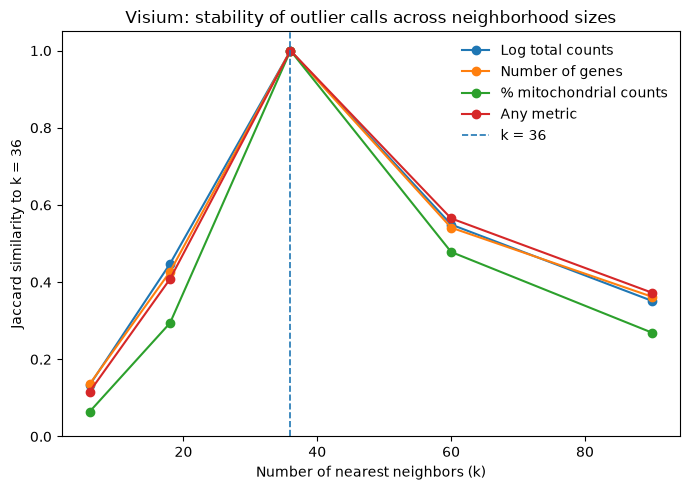

In [32]:
fig, ax = plot_jaccard_vs_k(
    visium_jaccard,
    reference_k=VISIUM_DEFAULT_K,
    title="Visium: stability of outlier calls across neighborhood sizes",
)

plt.show()

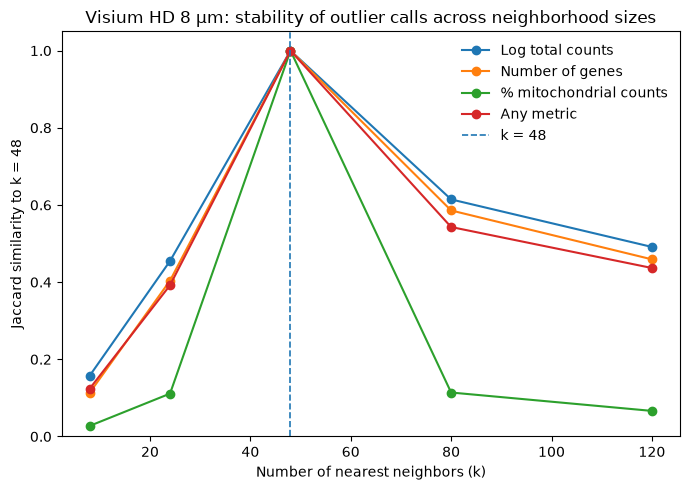

In [33]:
fig, ax = plot_jaccard_vs_k(
    hd8_jaccard,
    reference_k=HD8_DEFAULT_K,
    title="Visium HD 8 µm: stability of outlier calls across neighborhood sizes",
)

plt.show()

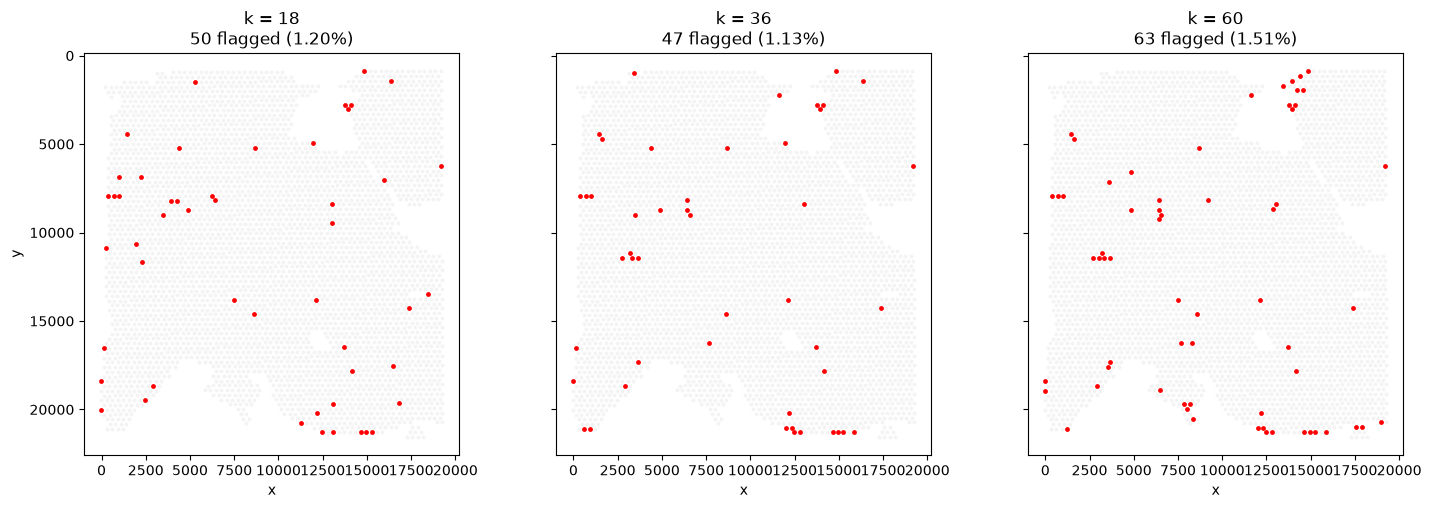

In [26]:
coords = np.asarray(visium.obsm["spatial"])
x, y = coords[:, 0], coords[:, 1]

k_values = [18, 36, 60]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, k in zip(axes, k_values):
    flag = visium.obs[f"log_total_counts_outliers_k{k}"].astype(bool).to_numpy()

    ax.scatter(x, y, s=8, c="lightgray", alpha=0.25, linewidths=0)
    ax.scatter(x[flag], y[flag], s=12, c="red", linewidths=0)

    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(f"k = {k}\n{flag.sum()} flagged ({flag.mean()*100:.2f}%)")
    ax.set_xlabel("x")

axes[0].set_ylabel("y")

plt.tight_layout()
plt.show()

Stitch the figures together

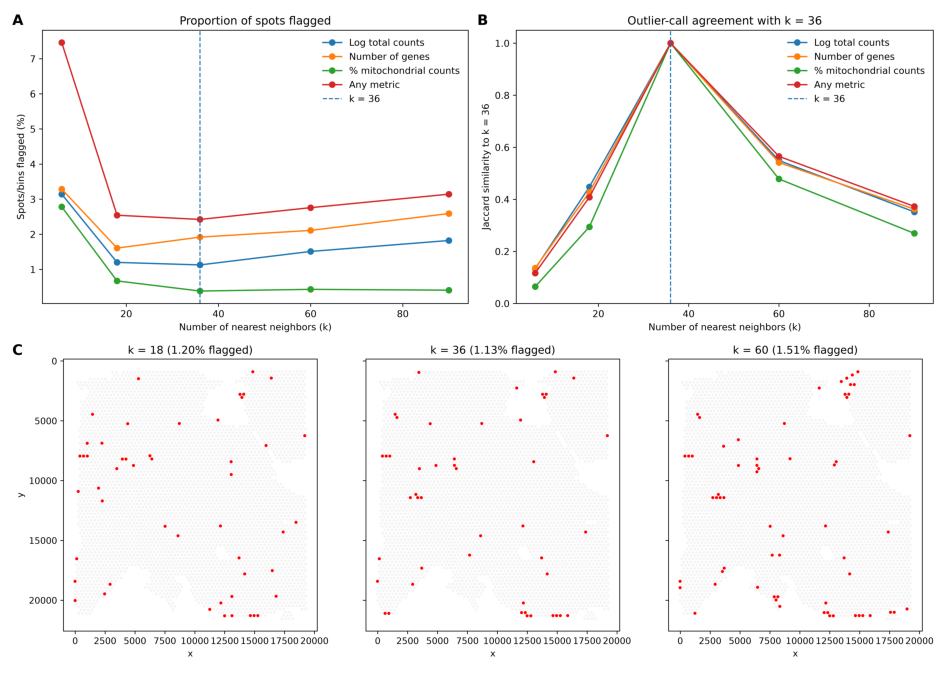

In [35]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import numpy as np

OUTDIR = "/users/xchen5/revisions_SpotSweeper-py/figures"

# ============================================================
# PANEL A: proportion flagged vs k
# ============================================================
figA, ax = plot_flagged_vs_k(
    visium_summary,
    title="Proportion of spots flagged",
    reference_k=VISIUM_DEFAULT_K,
)

figA.savefig(
    f"{OUTDIR}/Sensitivity_panel_A.png",
    dpi=600,
    bbox_inches="tight"
)
plt.close(figA)


# ============================================================
# PANEL B: Jaccard similarity vs k
# ============================================================
figB, ax = plot_jaccard_vs_k(
    visium_jaccard,
    reference_k=VISIUM_DEFAULT_K,
    title="Outlier-call agreement with k = 36",
)

figB.savefig(
    f"{OUTDIR}/Sensitivity_panel_B.png",
    dpi=600,
    bbox_inches="tight"
)
plt.close(figB)


# ============================================================
# PANEL C: spatial stability, k = 18 / 36 / 60
# ============================================================
coords = np.asarray(visium.obsm["spatial"])
x, y = coords[:, 0], coords[:, 1]

k_values = [18, 36, 60]

figC, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),
    sharex=True,
    sharey=True
)

for ax, k in zip(axes, k_values):
    flag = (
        visium.obs[f"log_total_counts_outliers_k{k}"]
        .astype(bool)
        .to_numpy()
    )

    ax.scatter(
        x, y,
        s=8,
        c="lightgray",
        alpha=0.25,
        linewidths=0
    )

    ax.scatter(
        x[flag], y[flag],
        s=12,
        c="red",
        linewidths=0
    )

    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(
        f"k = {k} ({flag.mean()*100:.2f}% flagged)"
    )
    ax.set_xlabel("x")

axes[0].set_ylabel("y")

plt.tight_layout()

figC.savefig(
    f"{OUTDIR}/Sensitivity_panel_C.png",
    dpi=600,
    bbox_inches="tight"
)
plt.close(figC)


# ============================================================
# STITCH:
# top row = A | B
# bottom row = C spanning full width
# ============================================================
A = Image.open(f"{OUTDIR}/Sensitivity_panel_A.png").convert("RGB")
B = Image.open(f"{OUTDIR}/Sensitivity_panel_B.png").convert("RGB")
C = Image.open(f"{OUTDIR}/Sensitivity_panel_C.png").convert("RGB")


def resize_to_h(im, H):
    w = int(im.width * H / im.height)
    return im.resize((w, H), Image.Resampling.LANCZOS)


# Make A and B same height
H_top = max(A.height, B.height)
A = resize_to_h(A, H_top)
B = resize_to_h(B, H_top)

top = Image.new(
    "RGB",
    (A.width + B.width, H_top),
    "white"
)
top.paste(A, (0, 0))
top.paste(B, (A.width, 0))


# Resize C to width of top row
W = top.width
C_h = int(C.height * W / C.width)
C = C.resize(
    (W, C_h),
    Image.Resampling.LANCZOS
)

# Stack rows
out = Image.new(
    "RGB",
    (W, top.height + C.height),
    "white"
)

out.paste(top, (0, 0))
out.paste(C, (0, top.height))


# ============================================================
# PANEL LABELS
# ============================================================
draw = ImageDraw.Draw(out)

try:
    font = ImageFont.truetype(
        "DejaVuSans-Bold.ttf",
        size=128
    )
except IOError:
    font = ImageFont.load_default()


def label(x, y, text):
    pad = 10
    bbox = draw.textbbox(
        (x, y),
        text,
        font=font
    )

    draw.rectangle(
        (
            bbox[0] - pad,
            bbox[1] - pad,
            bbox[2] + pad,
            bbox[3] + pad
        ),
        fill="white"
    )

    draw.text(
        (x, y),
        text,
        fill="black",
        font=font
    )


margin = 20

label(margin, margin, "A")
label(A.width + margin, margin, "B")
label(margin, top.height + margin, "C")


# ============================================================
# FINAL TIFF EXPORT
# ============================================================
out.save(
    f"{OUTDIR}/Figure_Sensitivity_k.tif",
    dpi=(300, 300),
    compression="tiff_lzw"
)


# Show final stitched figure only
plt.figure(figsize=(12, 10))
plt.imshow(out)
plt.axis("off")
plt.show()